# Phase 6, Milestone 3: joint two-asset barrier options

This notebook is the reproducible computational record for
`PHASE_6_MILESTONE_3_JOINT_BARRIER.md`. It verifies:

1. the **clock moments** \(E[A_T]\), \(\mathrm{Var}(A_T)\) from
   deterministic Gauss quadrature against Monte Carlo;
2. the **DDS reduction theorem** itself: a full three-driver Monte
   Carlo of \((F_1,F_2,\rho)\) with bridge-corrected barrier crossing
   against the scalar reduction (simulate only the correlation driver,
   evaluate a closed form), at two step sizes;
3. the **Gamma moment-matched price** against the exact simulation
   benchmark, with the approximation error *measured* per parameter
   set;
4. the **sign prediction**: correlation risk moves spread and basket
   barrier prices in opposite directions relative to the
   constant-correlation benchmark.

Seed `20260727`. Numerical evidence supports the derivations; it does
not replace them.

In [1]:
from pathlib import Path
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_joint.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_joint.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_joint as pj

SEED = 20260727
rng = np.random.default_rng(SEED)

FIGURES = ROOT / "phase6_figures"
FIGURES.mkdir(exist_ok=True)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. Parameters

Correlation driver \(X_t=x_0+\mu t+\sigma W_t\) (as in Milestones 1–2)
and two normal-vol assets. The spread one-touch pays 1 if
\(F_1-F_2\) rises by `DISTANCE` above its start.

In [2]:
DRIVER = dict(x0=0.0, drift=0.3, volatility=0.8, scale=1.0)
SIGMA1, SIGMA2 = 1.5, 2.5
MATURITY = 1.0
DISTANCE = 2.0
RATE = 0.05
N_PATHS = 100_000

def q_spread(rho):
    return pj.q_variance(rho, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2)

def q_basket(rho):
    return pj.q_variance(rho, alpha1=1.0, alpha2=1.0, sigma1=SIGMA1, sigma2=SIGMA2)

## 2. Clock moments: quadrature vs. Monte Carlo

In [3]:
def simulate_driver_functionals(n_paths, horizon, step, seed, q_fn=None, driver=None):
    # Exact Gaussian skeleton of X evaluated on the fly (no path storage).
    # Returns per-path A_T = trapezoid integral of rho_t and, if q_fn is
    # given, v_T = trapezoid integral of q(rho_t).
    driver = DRIVER if driver is None else driver
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    state = np.full(n_paths, driver["x0"])
    rho_prev = state / np.sqrt(state**2 + driver["scale"]**2)
    a_acc = np.zeros(n_paths)
    v_acc = np.zeros(n_paths)
    sd = driver["volatility"] * np.sqrt(step)
    for _ in range(n_steps):
        state = state + driver["drift"] * step + sd * local_rng.standard_normal(n_paths)
        rho = state / np.sqrt(state**2 + driver["scale"]**2)
        a_acc += 0.5 * (rho_prev + rho) * step
        if q_fn is not None:
            v_acc += 0.5 * (q_fn(rho_prev) + q_fn(rho)) * step
        rho_prev = rho
    return a_acc, v_acc

STEP = 1e-3
a_mc, _ = simulate_driver_functionals(N_PATHS, MATURITY, STEP, SEED)
mean_q, var_q = pj.occupation_moments(MATURITY, **DRIVER)
mean_mc, var_mc = a_mc.mean(), a_mc.var(ddof=1)
se_mean = a_mc.std(ddof=1) / np.sqrt(N_PATHS)
se_var = var_mc * np.sqrt(2.0 / N_PATHS)  # Gaussian-scale asymptotic SE
print(f"E[A_T]   quadrature {mean_q:.6f} | MC {mean_mc:.6f} ± {2*se_mean:.6f} (2 SE) | z = {(mean_mc-mean_q)/se_mean:+.2f}")
print(f"Var(A_T) quadrature {var_q:.6f} | MC {var_mc:.6f} ± {2*se_var:.6f} (2 SE) | z = {(var_mc-var_q)/se_var:+.2f}")

E[A_T]   quadrature 0.106629 | MC 0.105725 ± 0.002113 (2 SE) | z = -0.86
Var(A_T) quadrature 0.111738 | MC 0.111642 ± 0.000999 (2 SE) | z = -0.19


## 3. The reduction theorem: full three-driver MC vs. scalar reduction

Full MC simulates \((W_1,W_2,X)\), builds the spread path, and applies
a bridge crossing correction with per-step conditional variance
\(q(\rho_t)\Delta t\). The reduction simulates only \(X\) and
evaluates \(2(1-\Phi(d/\sqrt{v(T)}))\) per path.

In [4]:
def full_spread_touch_mc(step, n_paths, seed):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(MATURITY / step))
    state_x = np.zeros(n_paths)
    state_z = np.zeros(n_paths)
    alive_idx = np.arange(n_paths)
    hit = np.zeros(n_paths, dtype=bool)
    sd_w = np.sqrt(step)
    for k in range(n_steps):
        if state_x.size == 0:
            break
        old_x, old_z = state_x, state_z
        new_x = (old_x + DRIVER["drift"] * step
                 + DRIVER["volatility"] * sd_w * local_rng.standard_normal(old_x.size))
        rho = new_x / np.sqrt(new_x**2 + DRIVER["scale"]**2)  # step-end correlation
        d_w1 = sd_w * local_rng.standard_normal(old_x.size)
        d_w2 = sd_w * local_rng.standard_normal(old_x.size)
        new_z = old_z + (SIGMA1 - SIGMA2 * rho) * d_w1 - SIGMA2 * np.sqrt(1 - rho**2) * d_w2
        v_step = q_spread(rho) * step
        crossed = new_z >= DISTANCE
        both_below = (old_z < DISTANCE) & (new_z < DISTANCE)
        bridge_prob = np.zeros(old_x.size)
        bridge_prob[both_below] = np.exp(
            -2.0 * (DISTANCE - old_z[both_below]) * (DISTANCE - new_z[both_below])
            / v_step[both_below]
        )
        crossed |= local_rng.random(old_x.size) < bridge_prob
        hit[alive_idx[crossed]] = True
        alive_idx = alive_idx[~crossed]
        state_x, state_z = new_x[~crossed], new_z[~crossed]
    return hit.mean(), hit.std() / np.sqrt(n_paths)

def reduction_touch_mc(step, n_paths, seed):
    _, v_clock = simulate_driver_functionals(n_paths, MATURITY, step, seed, q_fn=q_spread)
    probs = np.array([pj.driftless_touch_probability(DISTANCE, v) for v in v_clock])
    return probs.mean(), probs.std(ddof=1) / np.sqrt(n_paths), v_clock

exact_discount = np.exp(-RATE * MATURITY)
print(f"{'scheme':>26} {'estimate':>10} {'2 SE':>10}")
reduction_estimates = {}
for label, step in (("dt=1e-3", 1e-3), ("dt=2.5e-4", 2.5e-4)):
    p_full, se_full = full_spread_touch_mc(step, N_PATHS, SEED)
    p_red, se_red, _ = reduction_touch_mc(step, N_PATHS, SEED)
    reduction_estimates[label] = (p_red, se_red)
    print(f"{'full 3-driver ' + label:>26} {exact_discount*p_full:10.5f} {2*exact_discount*se_full:10.2e}")
    print(f"{'reduction ' + label:>26} {exact_discount*p_red:10.5f} {2*exact_discount*se_red:10.2e}")
    z = (p_full - p_red) / np.sqrt(se_full**2 + se_red**2)
    print(f"{'  z(full vs reduction)':>26} {z:10.2f}")

                    scheme   estimate       2 SE


     full 3-driver dt=1e-3    0.43194   3.00e-03
         reduction dt=1e-3    0.43371   4.66e-04
      z(full vs reduction)      -1.16


   full 3-driver dt=2.5e-4    0.43526   3.00e-03
       reduction dt=2.5e-4    0.43346   4.64e-04
      z(full vs reduction)       1.19


## 4. Gamma moment-matched price vs. exact benchmark

The Gamma match uses only the quadrature moments — fully deterministic.
Its error is measured against the reduction benchmark (fine grid) for
three driver volatilities. No blanket accuracy claim: the error is
reported per parameter set.

In [5]:
print(f"{'driver sigma':>13} {'E[v]':>8} {'Var(v)':>8} {'gamma':>9} {'benchmark':>10} {'2 SE':>9} {'gap':>9}")
for vol in (0.4, 0.8, 1.2):
    driver = {**DRIVER, "volatility": vol}
    mean_v, var_v = pj.clock_moments(
        MATURITY, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2, **driver
    )
    price_gamma = pj.gamma_touch_price(
        DISTANCE, maturity=MATURITY, rate=RATE, mean_clock=mean_v, var_clock=var_v
    )
    n_bench = 50_000
    _, v_clock = simulate_driver_functionals(
        n_bench, MATURITY, 1e-3, SEED + 1, q_fn=q_spread, driver=driver
    )
    probs = np.array([pj.driftless_touch_probability(DISTANCE, v) for v in v_clock])
    benchmark = exact_discount * probs.mean()
    se = exact_discount * probs.std(ddof=1) / np.sqrt(n_bench)
    print(f"{vol:13.1f} {mean_v:8.4f} {var_v:8.4f} {price_gamma:9.5f} {benchmark:10.5f} {2*se:9.2e} {price_gamma-benchmark:+9.2e}")

 driver sigma     E[v]   Var(v)     gamma  benchmark      2 SE       gap


          0.4   7.5187   2.2321   0.43788    0.43768  3.83e-04 +1.99e-04


          0.8   7.7003   6.2853   0.43422    0.43324  6.55e-04 +9.70e-04


          1.2   7.8434   9.9480   0.43085    0.42842  8.45e-04 +2.44e-03


## 5. Sign prediction: spread vs. basket mispricing

Constant-correlation pricing (\(\sigma=0\), \(\rho\equiv\rho_0\))
against stochastic-correlation pricing as driver volatility grows.
The gaps must have opposite signs for spread and basket.

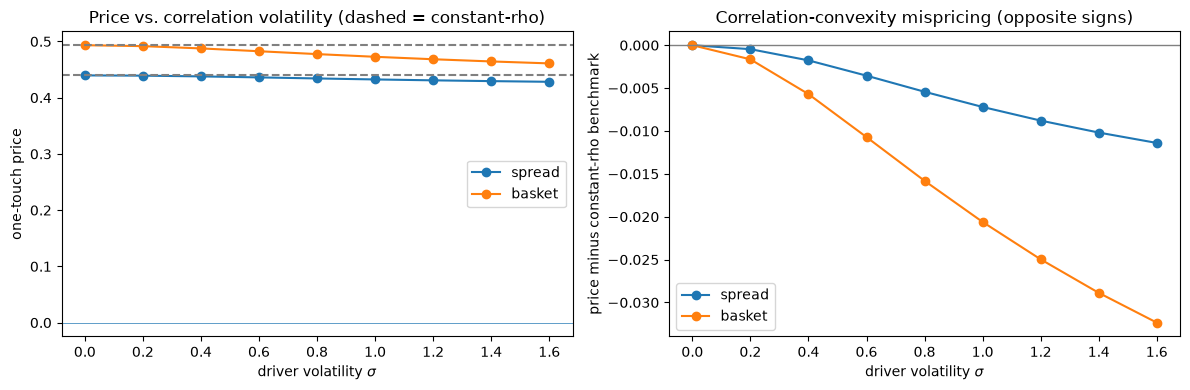

In [6]:
vols = np.linspace(0.0, 1.6, 9)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (name, q_fn, alpha2) in zip(axes, (("spread", q_spread, -1.0), ("basket", q_basket, 1.0))):
    prices, bench = [], None
    for vol in vols:
        driver = {**DRIVER, "volatility": vol}
        mean_v, var_v = pj.clock_moments(
            MATURITY, alpha1=1.0, alpha2=alpha2, sigma1=SIGMA1, sigma2=SIGMA2, **driver
        )
        prices.append(pj.gamma_touch_price(
            DISTANCE, maturity=MATURITY, rate=RATE, mean_clock=mean_v, var_clock=var_v
        ))
        if bench is None:
            bench = prices[0]
    axes[0].plot(vols, prices, "o-", label=name)
    axes[0].axhline(bench, ls="--", color="gray")
    axes[1].plot(vols, np.array(prices) - bench, "o-", label=name)
axes[0].axhline(0.0, lw=0.5)
axes[1].axhline(0.0, color="gray", lw=1)
axes[0].set_xlabel(r"driver volatility $\sigma$"); axes[0].set_ylabel("one-touch price")
axes[0].set_title("Price vs. correlation volatility (dashed = constant-rho)")
axes[1].set_xlabel(r"driver volatility $\sigma$"); axes[1].set_ylabel("price minus constant-rho benchmark")
axes[1].set_title("Correlation-convexity mispricing (opposite signs)")
for axis in axes:
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase6_joint_spread_vs_basket.png", dpi=150)
plt.show()

## 6. Runtime and reproducibility record

In [7]:
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 27.0 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
